In [1]:
import os
from datetime import date
from functools import partial
from typing import Optional, Union

import matplotlib.pyplot as plt
import numpy as np
import porepy as pp

from src.tpflab.ml.rel_perm import brookscorey_w, error_func_deriv
from src.tpflab.models.run_models import run_time_dependent_model
from src.tpflab.models.two_phase_flow import TwoPhaseFlow
from src.tpflab.numerics.ad.functions import pow
from src.tpflab.utils import rm_out_padding

rm_out_padding()

### Setup
For the problem setup, look into `two_phase_flow_setup_runs.ipynb`.

In [2]:
w_source_cell_index = 209

class TwoPhaseFlow_WSource(TwoPhaseFlow):
    def _source_w(self, g: pp.Grid) -> np.ndarray:
        array: np.ndarray = super()._source_w(g)
        array[w_source_cell_index] = 0.5
        return array

#### Introducing an artifical error in the relative permeability models

To test out when the model break, we manually add an increasing error
$$
y_{scale}\cdot e^{-x_{scale}(S_w-offset)^2}
$$
(this is the derivative of the error function $y_{scale}\cdot err(\sqrt{x_{scale}}(S_w-offset))$) to the wetting permeability.
By default, $x_{scale}=200$ and $offset=0.5$. We vary $y_{scale}$ to influence the size
of the error.

In [3]:
n1 = 2.0
n2= 3.0
n3 = 1.0
residual_sat_w = 0.3
residual_sat_n = 0.3

In [4]:
for yscale in np.arange(0.1, 0.4, 0.05):
    # Plot the wetting rel perm with the artifical error
    xx = np.arange(0, 1, 0.01)
    plt.plot(
        xx,
        brookscorey_w(
            xx,
            n1=n1,
            n2=n2,
            n3=n3,
            residual_sat_w=residual_sat_w,
            residual_sat_n=residual_sat_n
        ) 
        + error_func_deriv(xx, yscale=yscale, xscale=200, offset=0.5),
        label=f"$k_{{r,w}}$ + ${yscale:.2f}\cdot e^{{-200(S_w-0.5)}}$",
    )
plt.xlabel("$S_w$")
plt.ylabel("$\hat{k}_{r,w}$")
plt.legend()
plt.savefig(os.path.join("results",
    "artificial_error_tests",
    "artifical_error_relperm_w",
    f"{date.today().strftime('%Y-%m-%d')}_w_relperm_Brooks-Corey+Error.png"
    ))

TypeError: brookscorey_w() got an unexpected keyword argument 'n1'

In [5]:
from src.tpflab.numerics.ad.functions import minimum

class TwoPhaseFlow_WSource_RelPermWError(TwoPhaseFlow_WSource):

    def _rel_perm_w(self) -> pp.ad.Operator:
        """Wetting phase relative permeability pressure computed with the Corey
        model plus some error.
        """
        normalized_s = self._s_normalized()
        cube_func = pp.ad.Function(
            partial(pow, exponent=3), "cube"
        )
        rel_perm = cube_func(normalized_s) * self._rel_perm_linear_param + self._error_function_deriv()
        if self._limit_rel_perm:
            # TODO: Fix this so it applies to all subdomains.
            # min_value = np.full(
            #     self.mdg.subdomains()[0].num_cells, self._min_n_rel_perm
            # )
            maximum_func = pp.ad.Function(
                partial(pp.ad.functions.maximum, var_1=self._rel_perm_w_min), "max"
            )
            minimum_func = pp.ad.Function(
                partial(minimum, var_1=self._rel_perm_w_max), "min"
            )
            return minimum_func(maximum_func(rel_perm))
        else:
            return rel_perm

In [6]:
for yscale in np.arange(0.1, 0.5, 0.05):
    model = TwoPhaseFlow_WSource_RelPermWError(
        {
            "formulation": "n_pressure_w_saturation",
            "file_name": f"Brooks-Corey+Error_yscale{yscale:.2f}",
            "folder_name": os.path.join(
                "results",
                "artificial_error_tests",
                "artifical_error_relperm_w",
                f"{date.today().strftime('%Y-%m-%d')}_pcapmodel_None_relpermmodel_Brooks-Corey_wsourcecellindex_{w_source_cell_index}"
                ),
        }
    )
    model._cap_pressure_model = "None"
    model._yscale = yscale
    model._schedule: np.ndarray = np.array([0, 20.0])
    try:
        run_time_dependent_model(model, {"max_iterations": 30})
    except:
        pass

time loop:   0%|          | 0/101 [00:00<?, ?it/s]

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

time loop:   0%|          | 0/101 [00:00<?, ?it/s]

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

time loop:   0%|          | 0/101 [00:00<?, ?it/s]

...

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

time loop:   0%|          | 0/101 [00:00<?, ?it/s]

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

time loop:   0%|          | 0/101 [00:00<?, ?it/s]

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
for yscale in np.arange(0.1, 0.101, 0.0001):
    model = TwoPhaseFlow_WSource_RelPermWError(
        {
            "formulation": "n_pressure_w_saturation",
            "file_name": f"Brooks-Corey+Error_yscale{yscale:.4f}",
            "folder_name": os.path.join(
                "results",
                "artificial_error_tests",
                "artifical_error_relperm_w",
                f"{date.today().strftime('%Y-%m-%d')}_pcapmodel_linear_relpermmodel_Brooks-Corey_wsourcecellindex_{w_source_cell_index}"
                ),
        }
    )
    model._cap_pressure_model = "linear"
    model._yscale = yscale
    model._schedule: np.ndarray = np.array([0, 20.0])
    try:
        run_time_dependent_model(model, {"max_iterations": 30})
    except:
        pass

In [ ]:
for yscale in np.arange(0.1, 0.5, 0.05):
    model = TwoPhaseFlow_WSource_RelPermWError(
        {
            "formulation": "n_pressure_w_saturation",
            "file_name": f"Brooks-Corey+Error_yscale{yscale:.2f}",
            "folder_name": os.path.join(
                "results",
                "artificial_error_tests",
                "artifical_error_relperm_w",
                f"{date.today().strftime('%Y-%m-%d')}_pcapmodel_van_Genuchten_relpermmodel_Brooks-Corey_wsourcecellindex_{w_source_cell_index}"
                ),
        }
    )
    model._cap_pressure_model = "van Genuchten"
    model._yscale = yscale
    model._schedule: np.ndarray = np.array([0, 20.0])
    try:
        run_time_dependent_model(model, {"max_iterations": 30})
    except:
        pass

In [ ]:
for yscale in np.arange(0.05, 0.15, 0.01):
    model = TwoPhaseFlow_WSource_RelPermWError(
        {
            "formulation": "n_pressure_w_saturation",
            "file_name": f"Brooks-Corey+Error_yscale{yscale:.2f}",
            "folder_name": os.path.join(
                "results",
                "artificial_error_tests",
                "artifical_error_relperm_w",
                f"{date.today().strftime('%Y-%m-%d')}_pcapmodel_Brooks-Corey_relpermmodel_Brooks-Corey_wsourcecellindex_{w_source_cell_index}"
                ),
        }
    )
    model._cap_pressure_model = "Brooks-Corey"
    model._yscale = yscale
    model._schedule: np.ndarray = np.array([0, 20.0])
    try:
        run_time_dependent_model(model, {"max_iterations": 30})
    except:
        pass

Next we visualize the error curves!

In [ ]:
import json

colors = ["red", "blue"]
color = colors[0]

for yscale in np.arange(0.05, 0.15, 0.01):
    plt.figure()
    filename = os.path.join(
                "results",
                "artificial_error_tests",
                "artifical_error_relperm_w",
                f"{date.today().strftime('%Y-%m-%d')}_pcapmodel_Brooks-Corey_relpermmodel_Brooks-Corey_wsourcecellindex_{w_source_cell_index}"
                f"Brooks-Corey+Error_yscale{yscale:.2f}"
                )
    try:
        f = open(filename + '.txt')
    except:
        continue
    timestep: int = 0
    errors = []
    total_iteration = 0
    for line in f:
        try:
            data = json.loads(line)
        except json.JSONDecodeError as e:
            continue
        if "time step" in data:
            timestep = data["time step"]
        elif "error norm" in data:
            errors.append(data["error norm"])
            total_iteration += 1
        elif "converged" in data:
            plt.plot(range(total_iteration - len(errors), total_iteration), errors, color=color)
            color = colors[colors.index(color) - 1]
            errors = []
        else:
            continue
    plt.xlabel("iteration")
    plt.ylabel("error norm")
    plt.yscale('log')
    plt.savefig(filename + '.png')

#### Varying the position of the source
We observed by accident that the stability is very dependent on the position of the
wetting source. Thus we test out different positions, i.e.
$$
f_{w,i}=\begin{cases}
0.2,\quad&\text{if }i=I,\\
0,&\text{otherwise},
\end{cases}
$$
where $V_{I}=\{(x,y)\mid 0.9\leq x\leq1, k\cdot0.2\leq y\leq k\cdot0.2+0.1\}$ and we
vary $k.$

In [5]:
class TwoPhaseFlow_RelPermWError(TwoPhaseFlow):

    def _rel_perm_w(self) -> pp.ad.Operator:
        """Wetting phase relative permeability pressure computed with the Brooks Corey
        model plus some error.
        """
        s = self._ad.saturation
        normalized_s = (s - self._residual_w_saturation) / (
            1 - self._residual_n_saturation - self._residual_w_saturation
        )
        if self._rel_perm_model == "Brooks-Corey":
            power_func = pp.ad.Function(
                partial(pow, exponent=self._n1 + self._n2 * self._n3), "power"
            )
            return power_func(normalized_s) + self._error_function_deriv()
        else:
            return s * 0


class VaryingWSourceModel(TwoPhaseFlow_RelPermWError):

    def __init__(self, params: Optional[dict] = None) -> None:
        super().__init__(params)
        self._w_source_x_index: int = 10
        self._w_source_y_index: int = 10

    def _source_w(self, g: pp.Grid) -> np.ndarray:
        cell_index = self._w_source_y_index * 20 + self._w_source_x_index
        array: np.ndarray = super()._source_w(g)
        array[cell_index] = 0.5
        return array

time loop:   0%|          | 0/101 [00:00<?, ?it/s]

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

/home/peter/miniconda3/envs/tpf_dev/lib/python3.10/site-packages/porepy/models/abstract_model.py:286: UserWarning: PyPardiso could not be imported,
                    falling back on scipy.sparse.linalg.spsolve
  warnings.warn(


Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

...

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

time loop:   0%|          | 0/101 [00:00<?, ?it/s]

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

time loop:   0%|          | 0/101 [00:00<?, ?it/s]

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

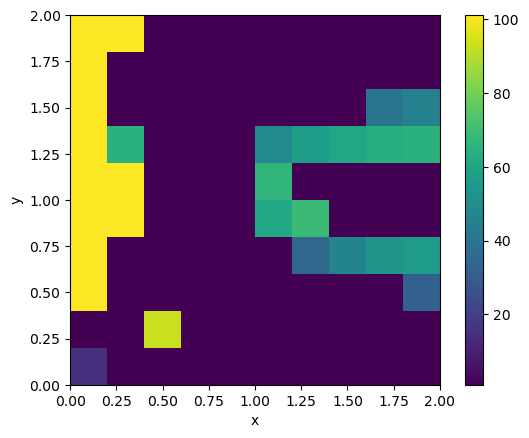

In [6]:
y_scale = 0.15
cap_pressure_model = "Brooks-Corey"

failure_time_indices = []

for x_index in range(0, 20, 2):
    failure_time_indices_y = []
    for y_index in range(0, 20, 2):
        model = VaryingWSourceModel(
            {
                "formulation": "n_pressure_w_saturation",
                "file_name": f"{date.today().strftime('%Y-%m-%d')}_Brooks-Corey+Error_yscale_{y_scale}",
                "folder_name": os.path.join(
                    "results",
                    "artificial_error_tests",
                    "artifical_error_relperm_w",
                    "varying_w_source_position",
                    f"{date.today().strftime('%Y-%m-%d')}_pcapmodel_{cap_pressure_model}_relpermmodel_Brooks-Corey_Brooks-Corey+Error_yscale_{y_scale}",
                    f"y_source_index_{y_index}_x_source_index_{x_index}"
                    ),
            }
        )
        model._cap_pressure_model = cap_pressure_model
        model._yscale = y_scale
        model._w_source_x_index = x_index
        model._w_source_y_index = y_index
        model._schedule: np.ndarray = np.array([0, 20.0])
        try:
            run_time_dependent_model(model, {"max_iterations": 30})
        except Exception:
            pass
        failure_time_indices_y.append(model.time_manager.time_index)
    failure_time_indices.append(failure_time_indices_y)

with open(os.path.join(
    "results",
    "artificial_error_tests",
    "artifical_error_relperm_w",
    "varying_w_source_position",
    f"{date.today().strftime('%Y-%m-%d')}_pcapmodel_{cap_pressure_model}_relpermmodel_Brooks-Corey_Brooks-Corey+Error_yscale_{y_scale}",
    "failure_timesteps.txt"), "w") as f:
    json.dump(failure_time_indices, f)
plt.imshow(np.array(failure_time_indices), extent=(0, 2, 0, 2), origin="lower")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()
plt.savefig(os.path.join(
    "results",
    "artificial_error_tests",
    "artifical_error_relperm_w",
    "varying_w_source_position",
    f"{date.today().strftime('%Y-%m-%d')}_pcapmodel_{cap_pressure_model}_relpermmodel_Brooks-Corey_Brooks-Corey+Error_yscale_{y_scale}",
    "failure_timesteps.png"))

#### Varying the offset
As the initial wetting saturation is $S_w=0.5$ for all grid cells, it is in the region of the
rel. perm. curve with the artificial error. To test out the influence of the error (and
also the monotonically increasing part of the error vs. the monotonically decreasing
part of the error), we vary the offset $offset\in\{0.4, 0.6\}.$

time loop:   0%|          | 0/51 [00:00<?, ?it/s]

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

/home/peter/miniconda3/envs/tpf_dev/lib/python3.10/site-packages/porepy/models/abstract_model.py:286: UserWarning: PyPardiso could not be imported,
                    falling back on scipy.sparse.linalg.spsolve
  warnings.warn(


Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

...

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

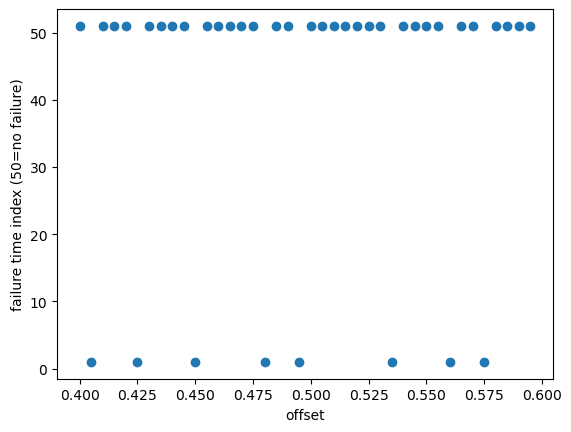

In [4]:
y_scale = 0.9
cap_pressure_model = "Brooks-Corey"

failure_time_indices = []

offsets = np.arange(0.4, 0.6, 0.005)

for offset in offsets:
    model = TwoPhaseFlow_WSource_RelPermWError(
            {
                "file_name": f"{date.today().strftime('%Y-%m-%d')}_Brooks-Corey+Error_yscale_{y_scale}",
                "folder_name": os.path.join(
                    "results",
                    "artificial_error_tests",
                    "artifical_error_relperm_w",
                    "varying_offset",
                    f"pcapmodel_{cap_pressure_model}_relpermmodel_Brooks-Corey_Brooks-Corey+Error_yscale_{y_scale}",
                    f"offset_{offset}"
                    ),
            }
        )

    model._formulation = "n_pressure_w_saturation"
    model._cap_pressure_model = "cap_pressure_model"
    model._yscale = y_scale
    model._offset = offset
    model._schedule: np.ndarray = np.array([0, 10.0])
    try:
        run_time_dependent_model(model, {"max_iterations": 30})
    except Exception:
        pass
    failure_time_indices.append(model.time_manager.time_index)

plt.scatter(offsets, np.array(failure_time_indices))
plt.xlabel("offset")
plt.ylabel("failure time index (50=no failure)")
plt.savefig(os.path.join(
    "results",
    "artificial_error_tests",
    "artifical_error_relperm_w",
    "varying_offset",
    f"pcapmodel_{cap_pressure_model}_relpermmodel_Brooks-Corey_Brooks-Corey+Error_yscale_{y_scale}",
    "failure_timesteps.png"))